# Pelatihan Model AI e-Sign (Prophet)


In [1]:
!pip install prophet statsmodels scikit-learn matplotlib

## 0. Generate Synthetic Data

In [2]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import os

# Install holidays jika belum ada
try:
    import holidays
except ImportError:
    import subprocess
    subprocess.check_call(['pip', 'install', 'holidays'])
    import holidays

def generate_synthetic_data(num_days=365):
    current_dir = '/content'

    # Ambil hari libur Indonesia
    id_holidays = holidays.ID(years=[datetime.now().year, datetime.now().year - 1, datetime.now().year + 1])

    # Konfigurasi beban per pegawai
    pegawai_configs = {
        '1a2394378ddbb186f6f622e8b3c872ee6872623f': {'base_nodin': 0, 'base_spt': 0, 'desc': 'staff'},
        '54a8b8362ebcb16af08c8acf33a2d8d5f335cf5e': {'base_nodin': 3, 'base_spt': 3, 'desc': 'pptk'},
        'ae914d89870f2450ca4c6ca9f34e3080317546e5': {'base_nodin': 5, 'base_spt': 8, 'desc': 'kabid'},
        '8018dcd81ff171aa9629c08d95422c20e45e307b': {'base_nodin': 12, 'base_spt': 15, 'desc': 'asekda'},
        'a4adb04d8392abc79d52ea247fabd8348b97a78a': {'base_nodin': 20, 'base_spt': 25, 'desc': 'sekda'},
    }

    end_date = datetime.now().date()
    start_date = end_date - timedelta(days=num_days - 1)
    date_rng = pd.date_range(start=start_date, end=end_date, freq='D')

    np.random.seed(42)

    for pegawai_id, config in pegawai_configs.items():
        data = []
        base_nodin = config['base_nodin']
        base_spt = config['base_spt']

        for dt in date_rng:
            date_str = dt.strftime('%Y-%m-%d')
            day_of_week = dt.weekday()
            month = dt.month

            if base_nodin == 0 and base_spt == 0:
                nodin = 0
                spt = 0
            else:
                # Cek apakah hari libur nasional
                if dt in id_holidays:
                    multiplier = np.random.uniform(0.0, 0.05)
                else:
                    if day_of_week in [0, 1, 2]: # Senin-Rabu
                        multiplier = np.random.uniform(1.0, 1.3)
                    elif day_of_week in [3, 4]: # Kamis-Jumat
                        multiplier = np.random.uniform(0.7, 1.0)
                    else: # Sabtu-Minggu libur
                        multiplier = np.random.uniform(0.0, 0.1)

                    if month in [11, 12]:
                        multiplier *= 1.3
                    elif month in [6, 7]:
                        multiplier *= 1.2

                nodin = int(base_nodin * multiplier) + np.random.randint(-2, 3)
                spt = int(base_spt * multiplier) + np.random.randint(-2, 3)

                nodin = max(0, nodin)
                spt = max(0, spt)

            data.append({
                'tanggal': date_str,
                'nodin': nodin,
                'spt': spt,
                'total': nodin + spt
            })

        df = pd.DataFrame(data)
        final_csv_path = os.path.join(current_dir, f'historical_data_pegawai_{pegawai_id}.csv')
        df.to_csv(final_csv_path, index=False)
        print(f"Berhasil membuat dataset untuk {config['desc']} -> {final_csv_path}")

generate_synthetic_data(365)



Berhasil membuat dataset untuk staff -> /content/historical_data_pegawai_1a2394378ddbb186f6f622e8b3c872ee6872623f.csv
Berhasil membuat dataset untuk pptk -> /content/historical_data_pegawai_54a8b8362ebcb16af08c8acf33a2d8d5f335cf5e.csv
Berhasil membuat dataset untuk kabid -> /content/historical_data_pegawai_ae914d89870f2450ca4c6ca9f34e3080317546e5.csv
Berhasil membuat dataset untuk asekda -> /content/historical_data_pegawai_8018dcd81ff171aa9629c08d95422c20e45e307b.csv
Berhasil membuat dataset untuk sekda -> /content/historical_data_pegawai_a4adb04d8392abc79d52ea247fabd8348b97a78a.csv


## 1. Import Library & Fungsi Pelatihan

In [3]:
import pandas as pd
import numpy as np
import os
import pickle
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings("ignore")

def train_and_save_models():
    pegawai_ids = [
        '1a2394378ddbb186f6f622e8b3c872ee6872623f',
        '54a8b8362ebcb16af08c8acf33a2d8d5f335cf5e',
        'ae914d89870f2450ca4c6ca9f34e3080317546e5',
        '8018dcd81ff171aa9629c08d95422c20e45e307b',
        'a4adb04d8392abc79d52ea247fabd8348b97a78a',
    ]

    current_dir = '/content'

    for pegawai_id in pegawai_ids:
        data_path = f'/content/historical_data_pegawai_{pegawai_id}.csv'
        if not os.path.exists(data_path):
            continue

        df = pd.read_csv(data_path)

        # Siapkan data Nodin
        print(f"Melatih model SARIMA Nodin untuk Pegawai {pegawai_id}...")
        try:
            model_sarima_nodin = SARIMAX(df['nodin'].values, order=(5,1,0), seasonal_order=(1,1,1,7)).fit(disp=False)
            with open(os.path.join(current_dir, f'model_sarima_nodin_pegawai_{pegawai_id}.pkl'), 'wb') as f:
                pickle.dump(model_sarima_nodin, f)
        except Exception as e:
            print(f"Gagal melatih nodin {pegawai_id}: {e}")

        # Siapkan data SPT
        print(f"Melatih model SARIMA SPT untuk Pegawai {pegawai_id}...")
        try:
            model_sarima_spt = SARIMAX(df['spt'].values, order=(5,1,0), seasonal_order=(1,1,1,7)).fit(disp=False)
            with open(os.path.join(current_dir, f'model_sarima_spt_pegawai_{pegawai_id}.pkl'), 'wb') as f:
                pickle.dump(model_sarima_spt, f)
        except Exception as e:
            print(f"Gagal melatih spt {pegawai_id}: {e}")

    print("\nModel AI (SARIMA) berhasil dilatih dan disimpan sebagai .pkl!")
    print("Silakan download file .pkl yang dihasilkan dari folder /content di menu sebelah kiri Colab.")

train_and_save_models()



Melatih model SARIMA Nodin untuk Pegawai 1a2394378ddbb186f6f622e8b3c872ee6872623f...
Melatih model SARIMA SPT untuk Pegawai 1a2394378ddbb186f6f622e8b3c872ee6872623f...
Melatih model SARIMA Nodin untuk Pegawai 54a8b8362ebcb16af08c8acf33a2d8d5f335cf5e...
Melatih model SARIMA SPT untuk Pegawai 54a8b8362ebcb16af08c8acf33a2d8d5f335cf5e...
Melatih model SARIMA Nodin untuk Pegawai ae914d89870f2450ca4c6ca9f34e3080317546e5...
Melatih model SARIMA SPT untuk Pegawai ae914d89870f2450ca4c6ca9f34e3080317546e5...
Melatih model SARIMA Nodin untuk Pegawai 8018dcd81ff171aa9629c08d95422c20e45e307b...
Melatih model SARIMA SPT untuk Pegawai 8018dcd81ff171aa9629c08d95422c20e45e307b...
Melatih model SARIMA Nodin untuk Pegawai a4adb04d8392abc79d52ea247fabd8348b97a78a...
Melatih model SARIMA SPT untuk Pegawai a4adb04d8392abc79d52ea247fabd8348b97a78a...

Model AI (SARIMA) berhasil dilatih dan disimpan sebagai .pkl!
Silakan download file .pkl yang dihasilkan dari folder /content di menu sebelah kiri Colab.


## 2. Evaluasi Model (Perbandingan MAE & RMSE)

Melatih model Prophet...
Melatih model ARIMA...
Melatih model SARIMA...

--- HASIL EVALUASI MODEL ---
Model                     | MAE        | RMSE
--------------------------------------------------
Prophet                   | 0.0000     | 0.0000
ARIMA                     | 0.0000     | 0.0000
SARIMA                    | 0.0000     | 0.0000


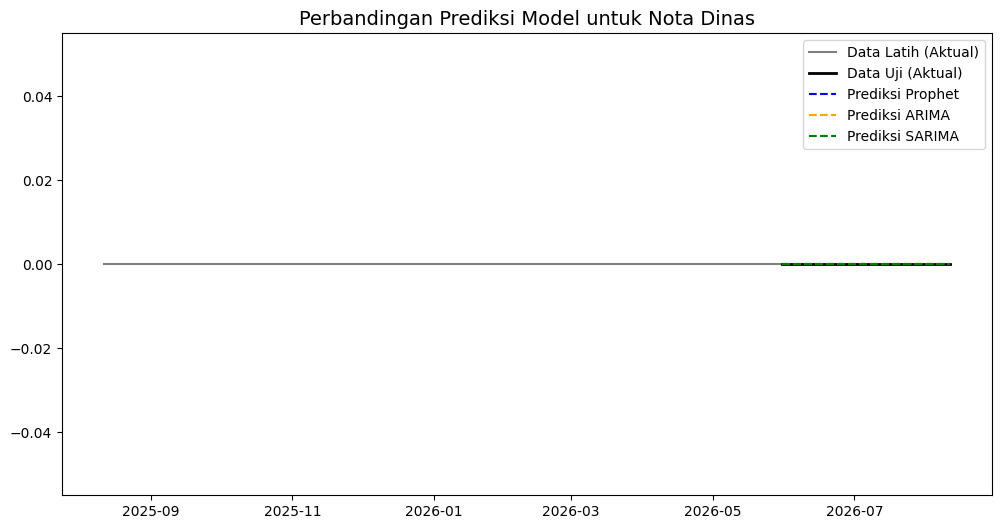

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from prophet import Prophet

def evaluate_models():
    pegawai_id = '1a2394378ddbb186f6f622e8b3c872ee6872623f'
    data_path = f'/content/historical_data_pegawai_{pegawai_id}.csv'

    if not os.path.exists(data_path):
        print("Jalankan cell generate data terlebih dahulu!")
        return

    df = pd.read_csv(data_path)
    df_eval = df[['tanggal', 'nodin']].rename(columns={'tanggal': 'ds', 'nodin': 'y'})
    df_eval['ds'] = pd.to_datetime(df_eval['ds'])
    df_eval = df_eval.sort_values('ds')

    train_size = int(len(df_eval) * 0.8)
    train_df = df_eval.iloc[:train_size].copy()
    test_df = df_eval.iloc[train_size:].copy()

    predictions = pd.DataFrame({'ds': test_df['ds'], 'Aktual': test_df['y']})

    print("Melatih model Prophet...")
    model_prophet = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
    model_prophet.fit(train_df)
    future = model_prophet.make_future_dataframe(periods=len(test_df))
    pred_prophet = model_prophet.predict(future)['yhat'].iloc[-len(test_df):].values
    predictions['Prophet'] = np.maximum(0, pred_prophet)

    print("Melatih model ARIMA...")
    try:
        model_arima_fit = ARIMA(train_df['y'].values, order=(5,1,0)).fit()
        predictions['ARIMA'] = np.maximum(0, model_arima_fit.forecast(steps=len(test_df)))
    except:
        predictions['ARIMA'] = 0

    print("Melatih model SARIMA...")
    try:
        # Order ARIMA + Seasonal Order
        model_sarima_fit = SARIMAX(train_df['y'].values, order=(5,1,0), seasonal_order=(1,1,1,7)).fit(disp=False)
        predictions['SARIMA'] = np.maximum(0, model_sarima_fit.forecast(steps=len(test_df)))
    except:
        predictions['SARIMA'] = 0


    models_to_eval = ['Prophet', 'ARIMA', 'SARIMA']

    print("\n--- HASIL EVALUASI MODEL ---")
    print(f"{'Model':<25} | {'MAE':<10} | {'RMSE'}")
    print("-" * 50)
    for m in models_to_eval:
        mae = mean_absolute_error(predictions['Aktual'], predictions[m])
        rmse = np.sqrt(mean_squared_error(predictions['Aktual'], predictions[m]))
        print(f"{m:<25} | {mae:<10.4f} | {rmse:.4f}")

    plt.figure(figsize=(12, 6))
    plt.plot(train_df['ds'], train_df['y'], label='Data Latih (Aktual)', color='gray')
    plt.plot(predictions['ds'], predictions['Aktual'], label='Data Uji (Aktual)', color='black', linewidth=2)
    colors = ['blue', 'orange', 'green']
    for idx, m in enumerate(models_to_eval):
        plt.plot(predictions['ds'], predictions[m], label=f'Prediksi {m}', color=colors[idx], linestyle='--')
    plt.title(f'Perbandingan Prediksi Model untuk Nota Dinas', fontsize=14)
    plt.legend()
    plt.show()

evaluate_models()

Melatih model Prophet...
Melatih model ARIMA...
Melatih model SARIMA...

--- HASIL EVALUASI MODEL ---
Model                     | MAE        | RMSE
--------------------------------------------------
Prophet                   | 1.5683     | 2.0507
ARIMA                     | 1.8480     | 2.2144
SARIMA                    | 1.4264     | 1.9024


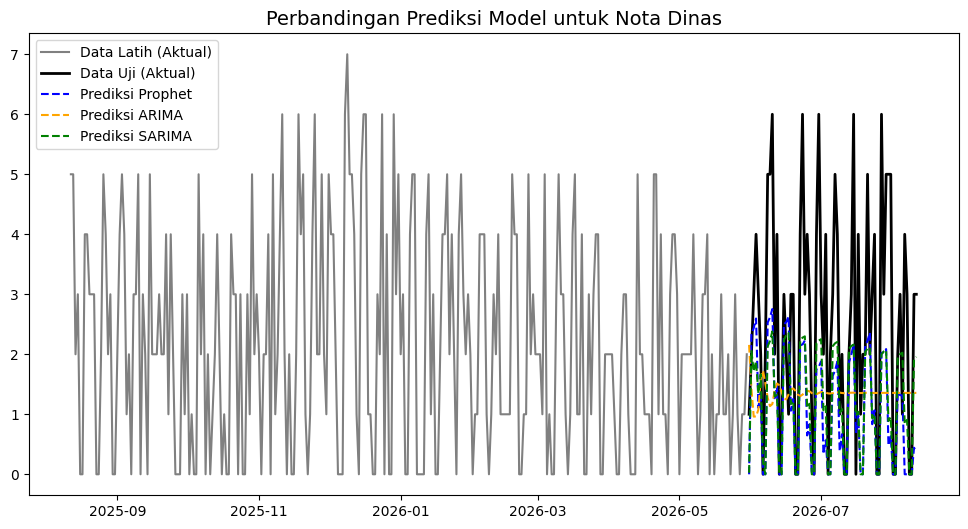

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from prophet import Prophet

def evaluate_models():
    pegawai_id = '54a8b8362ebcb16af08c8acf33a2d8d5f335cf5e'
    data_path = f'/content/historical_data_pegawai_{pegawai_id}.csv'

    if not os.path.exists(data_path):
        print("Jalankan cell generate data terlebih dahulu!")
        return

    df = pd.read_csv(data_path)
    df_eval = df[['tanggal', 'nodin']].rename(columns={'tanggal': 'ds', 'nodin': 'y'})
    df_eval['ds'] = pd.to_datetime(df_eval['ds'])
    df_eval = df_eval.sort_values('ds')

    train_size = int(len(df_eval) * 0.8)
    train_df = df_eval.iloc[:train_size].copy()
    test_df = df_eval.iloc[train_size:].copy()

    predictions = pd.DataFrame({'ds': test_df['ds'], 'Aktual': test_df['y']})

    print("Melatih model Prophet...")
    model_prophet = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
    model_prophet.fit(train_df)
    future = model_prophet.make_future_dataframe(periods=len(test_df))
    pred_prophet = model_prophet.predict(future)['yhat'].iloc[-len(test_df):].values
    predictions['Prophet'] = np.maximum(0, pred_prophet)

    print("Melatih model ARIMA...")
    try:
        model_arima_fit = ARIMA(train_df['y'].values, order=(5,1,0)).fit()
        predictions['ARIMA'] = np.maximum(0, model_arima_fit.forecast(steps=len(test_df)))
    except:
        predictions['ARIMA'] = 0

    print("Melatih model SARIMA...")
    try:
        # Order ARIMA + Seasonal Order
        model_sarima_fit = SARIMAX(train_df['y'].values, order=(5,1,0), seasonal_order=(1,1,1,7)).fit(disp=False)
        predictions['SARIMA'] = np.maximum(0, model_sarima_fit.forecast(steps=len(test_df)))
    except:
        predictions['SARIMA'] = 0


    models_to_eval = ['Prophet', 'ARIMA', 'SARIMA']

    print("\n--- HASIL EVALUASI MODEL ---")
    print(f"{'Model':<25} | {'MAE':<10} | {'RMSE'}")
    print("-" * 50)
    for m in models_to_eval:
        mae = mean_absolute_error(predictions['Aktual'], predictions[m])
        rmse = np.sqrt(mean_squared_error(predictions['Aktual'], predictions[m]))
        print(f"{m:<25} | {mae:<10.4f} | {rmse:.4f}")

    plt.figure(figsize=(12, 6))
    plt.plot(train_df['ds'], train_df['y'], label='Data Latih (Aktual)', color='gray')
    plt.plot(predictions['ds'], predictions['Aktual'], label='Data Uji (Aktual)', color='black', linewidth=2)
    colors = ['blue', 'orange', 'green']
    for idx, m in enumerate(models_to_eval):
        plt.plot(predictions['ds'], predictions[m], label=f'Prediksi {m}', color=colors[idx], linestyle='--')
    plt.title(f'Perbandingan Prediksi Model untuk Nota Dinas', fontsize=14)
    plt.legend()
    plt.show()

evaluate_models()

Melatih model Prophet...
Melatih model ARIMA...
Melatih model SARIMA...

--- HASIL EVALUASI MODEL ---
Model                     | MAE        | RMSE
--------------------------------------------------
Prophet                   | 2.0371     | 2.6134
ARIMA                     | 2.7753     | 3.2072
SARIMA                    | 1.5562     | 2.0444


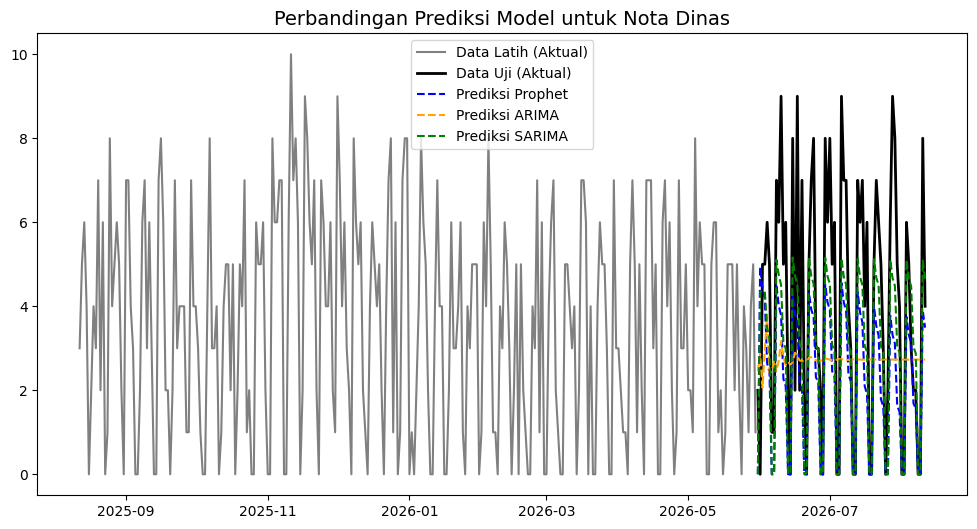

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from prophet import Prophet

def evaluate_models():
    pegawai_id = 'ae914d89870f2450ca4c6ca9f34e3080317546e5'
    data_path = f'/content/historical_data_pegawai_{pegawai_id}.csv'

    if not os.path.exists(data_path):
        print("Jalankan cell generate data terlebih dahulu!")
        return

    df = pd.read_csv(data_path)
    df_eval = df[['tanggal', 'nodin']].rename(columns={'tanggal': 'ds', 'nodin': 'y'})
    df_eval['ds'] = pd.to_datetime(df_eval['ds'])
    df_eval = df_eval.sort_values('ds')

    train_size = int(len(df_eval) * 0.8)
    train_df = df_eval.iloc[:train_size].copy()
    test_df = df_eval.iloc[train_size:].copy()

    predictions = pd.DataFrame({'ds': test_df['ds'], 'Aktual': test_df['y']})

    print("Melatih model Prophet...")
    model_prophet = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
    model_prophet.fit(train_df)
    future = model_prophet.make_future_dataframe(periods=len(test_df))
    pred_prophet = model_prophet.predict(future)['yhat'].iloc[-len(test_df):].values
    predictions['Prophet'] = np.maximum(0, pred_prophet)

    print("Melatih model ARIMA...")
    try:
        model_arima_fit = ARIMA(train_df['y'].values, order=(5,1,0)).fit()
        predictions['ARIMA'] = np.maximum(0, model_arima_fit.forecast(steps=len(test_df)))
    except:
        predictions['ARIMA'] = 0

    print("Melatih model SARIMA...")
    try:
        # Order ARIMA + Seasonal Order
        model_sarima_fit = SARIMAX(train_df['y'].values, order=(5,1,0), seasonal_order=(1,1,1,7)).fit(disp=False)
        predictions['SARIMA'] = np.maximum(0, model_sarima_fit.forecast(steps=len(test_df)))
    except:
        predictions['SARIMA'] = 0


    models_to_eval = ['Prophet', 'ARIMA', 'SARIMA']

    print("\n--- HASIL EVALUASI MODEL ---")
    print(f"{'Model':<25} | {'MAE':<10} | {'RMSE'}")
    print("-" * 50)
    for m in models_to_eval:
        mae = mean_absolute_error(predictions['Aktual'], predictions[m])
        rmse = np.sqrt(mean_squared_error(predictions['Aktual'], predictions[m]))
        print(f"{m:<25} | {mae:<10.4f} | {rmse:.4f}")

    plt.figure(figsize=(12, 6))
    plt.plot(train_df['ds'], train_df['y'], label='Data Latih (Aktual)', color='gray')
    plt.plot(predictions['ds'], predictions['Aktual'], label='Data Uji (Aktual)', color='black', linewidth=2)
    colors = ['blue', 'orange', 'green']
    for idx, m in enumerate(models_to_eval):
        plt.plot(predictions['ds'], predictions[m], label=f'Prediksi {m}', color=colors[idx], linestyle='--')
    plt.title(f'Perbandingan Prediksi Model untuk Nota Dinas', fontsize=14)
    plt.legend()
    plt.show()

evaluate_models()

Melatih model Prophet...
Melatih model ARIMA...
Melatih model SARIMA...

--- HASIL EVALUASI MODEL ---
Model                     | MAE        | RMSE
--------------------------------------------------
Prophet                   | 8.0225     | 9.5440
ARIMA                     | 6.8579     | 7.3912
SARIMA                    | 3.3310     | 4.2725


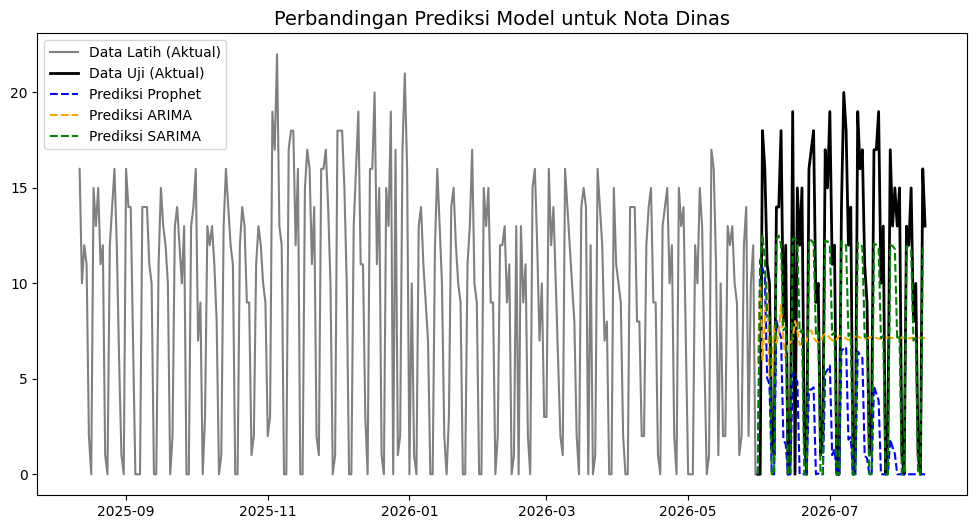

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from prophet import Prophet

def evaluate_models():
    pegawai_id = '8018dcd81ff171aa9629c08d95422c20e45e307b'
    data_path = f'/content/historical_data_pegawai_{pegawai_id}.csv'

    if not os.path.exists(data_path):
        print("Jalankan cell generate data terlebih dahulu!")
        return

    df = pd.read_csv(data_path)
    df_eval = df[['tanggal', 'nodin']].rename(columns={'tanggal': 'ds', 'nodin': 'y'})
    df_eval['ds'] = pd.to_datetime(df_eval['ds'])
    df_eval = df_eval.sort_values('ds')

    train_size = int(len(df_eval) * 0.8)
    train_df = df_eval.iloc[:train_size].copy()
    test_df = df_eval.iloc[train_size:].copy()

    predictions = pd.DataFrame({'ds': test_df['ds'], 'Aktual': test_df['y']})

    print("Melatih model Prophet...")
    model_prophet = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
    model_prophet.fit(train_df)
    future = model_prophet.make_future_dataframe(periods=len(test_df))
    pred_prophet = model_prophet.predict(future)['yhat'].iloc[-len(test_df):].values
    predictions['Prophet'] = np.maximum(0, pred_prophet)

    print("Melatih model ARIMA...")
    try:
        model_arima_fit = ARIMA(train_df['y'].values, order=(5,1,0)).fit()
        predictions['ARIMA'] = np.maximum(0, model_arima_fit.forecast(steps=len(test_df)))
    except:
        predictions['ARIMA'] = 0

    print("Melatih model SARIMA...")
    try:
        # Order ARIMA + Seasonal Order
        model_sarima_fit = SARIMAX(train_df['y'].values, order=(5,1,0), seasonal_order=(1,1,1,7)).fit(disp=False)
        predictions['SARIMA'] = np.maximum(0, model_sarima_fit.forecast(steps=len(test_df)))
    except:
        predictions['SARIMA'] = 0


    models_to_eval = ['Prophet', 'ARIMA', 'SARIMA']

    print("\n--- HASIL EVALUASI MODEL ---")
    print(f"{'Model':<25} | {'MAE':<10} | {'RMSE'}")
    print("-" * 50)
    for m in models_to_eval:
        mae = mean_absolute_error(predictions['Aktual'], predictions[m])
        rmse = np.sqrt(mean_squared_error(predictions['Aktual'], predictions[m]))
        print(f"{m:<25} | {mae:<10.4f} | {rmse:.4f}")

    plt.figure(figsize=(12, 6))
    plt.plot(train_df['ds'], train_df['y'], label='Data Latih (Aktual)', color='gray')
    plt.plot(predictions['ds'], predictions['Aktual'], label='Data Uji (Aktual)', color='black', linewidth=2)
    colors = ['blue', 'orange', 'green']
    for idx, m in enumerate(models_to_eval):
        plt.plot(predictions['ds'], predictions[m], label=f'Prediksi {m}', color=colors[idx], linestyle='--')
    plt.title(f'Perbandingan Prediksi Model untuk Nota Dinas', fontsize=14)
    plt.legend()
    plt.show()

evaluate_models()

Melatih model Prophet...
Melatih model ARIMA...
Melatih model SARIMA...

--- HASIL EVALUASI MODEL ---
Model                     | MAE        | RMSE
--------------------------------------------------
Prophet                   | 10.0321    | 11.9227
ARIMA                     | 11.7066    | 12.4443
SARIMA                    | 5.4779     | 6.9300


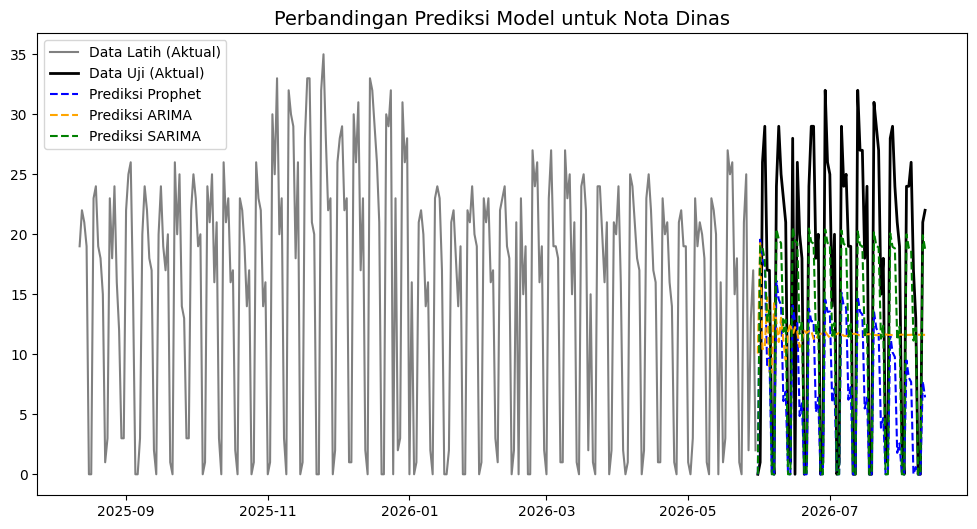

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from prophet import Prophet

def evaluate_models():
    pegawai_id = 'a4adb04d8392abc79d52ea247fabd8348b97a78a'
    data_path = f'/content/historical_data_pegawai_{pegawai_id}.csv'

    if not os.path.exists(data_path):
        print("Jalankan cell generate data terlebih dahulu!")
        return

    df = pd.read_csv(data_path)
    df_eval = df[['tanggal', 'nodin']].rename(columns={'tanggal': 'ds', 'nodin': 'y'})
    df_eval['ds'] = pd.to_datetime(df_eval['ds'])
    df_eval = df_eval.sort_values('ds')

    train_size = int(len(df_eval) * 0.8)
    train_df = df_eval.iloc[:train_size].copy()
    test_df = df_eval.iloc[train_size:].copy()

    predictions = pd.DataFrame({'ds': test_df['ds'], 'Aktual': test_df['y']})

    print("Melatih model Prophet...")
    model_prophet = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
    model_prophet.fit(train_df)
    future = model_prophet.make_future_dataframe(periods=len(test_df))
    pred_prophet = model_prophet.predict(future)['yhat'].iloc[-len(test_df):].values
    predictions['Prophet'] = np.maximum(0, pred_prophet)

    print("Melatih model ARIMA...")
    try:
        model_arima_fit = ARIMA(train_df['y'].values, order=(5,1,0)).fit()
        predictions['ARIMA'] = np.maximum(0, model_arima_fit.forecast(steps=len(test_df)))
    except:
        predictions['ARIMA'] = 0

    print("Melatih model SARIMA...")
    try:
        # Order ARIMA + Seasonal Order
        model_sarima_fit = SARIMAX(train_df['y'].values, order=(5,1,0), seasonal_order=(1,1,1,7)).fit(disp=False)
        predictions['SARIMA'] = np.maximum(0, model_sarima_fit.forecast(steps=len(test_df)))
    except:
        predictions['SARIMA'] = 0


    models_to_eval = ['Prophet', 'ARIMA', 'SARIMA']

    print("\n--- HASIL EVALUASI MODEL ---")
    print(f"{'Model':<25} | {'MAE':<10} | {'RMSE'}")
    print("-" * 50)
    for m in models_to_eval:
        mae = mean_absolute_error(predictions['Aktual'], predictions[m])
        rmse = np.sqrt(mean_squared_error(predictions['Aktual'], predictions[m]))
        print(f"{m:<25} | {mae:<10.4f} | {rmse:.4f}")

    plt.figure(figsize=(12, 6))
    plt.plot(train_df['ds'], train_df['y'], label='Data Latih (Aktual)', color='gray')
    plt.plot(predictions['ds'], predictions['Aktual'], label='Data Uji (Aktual)', color='black', linewidth=2)
    colors = ['blue', 'orange', 'green']
    for idx, m in enumerate(models_to_eval):
        plt.plot(predictions['ds'], predictions[m], label=f'Prediksi {m}', color=colors[idx], linestyle='--')
    plt.title(f'Perbandingan Prediksi Model untuk Nota Dinas', fontsize=14)
    plt.legend()
    plt.show()

evaluate_models()

In [10]:
from google.colab import files
import os
import zipfile

# Kumpulkan dan bungkus semua file .pkl ke dalam satu file .zip
with zipfile.ZipFile('model_sarima.zip', 'w') as zipf:
    for f in os.listdir('/content'):
        if f.endswith('.pkl'):
            zipf.write(f)

print("Berhasil mengompres file, memulai download...")

# Memaksa browser untuk langsung mendownload file zip-nya
files.download('model_sarima.zip')


Berhasil mengompres file, memulai download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>